In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM

In [12]:
df = pd.read_excel("Desktop/yahoo-finance-stock-data.xlsx")

df.head()

,Unnamed: 0,name,symbol,price_usd,change,volume_M,market_cap_B,pe_ratio
0,0,NVIDIA Corporation,NVDA,117.06,3.52,202.631,2856.000,39.82
1,1,"Lucid Group, Inc.",LCID,2.25,-0.08,135.525,6.863,NaN
2,2,Alphabet Inc.,GOOGL,151.38,-11.85,127.106,1845.000,16.90
3,3,Ford Motor Company,F,10.28,-0.16,116.758,40.879,8.22
4,4,Palantir Technologies Inc.,PLTR,110.48,1.62,95.041,260.723,480.35


# Data Cleaning

In [15]:
# Remove unnecessary columns
df = df.drop(columns=['name', 'symbol'])
df = df.dropna()

df.head()

,Unnamed: 0,price_usd,change,volume_M,market_cap_B,pe_ratio
0,0,117.06,3.52,202.631,2856.000,39.82
2,2,151.38,-11.85,127.106,1845.000,16.90
3,3,10.28,-0.16,116.758,40.879,8.22
4,4,110.48,1.62,95.041,260.723,480.35
5,5,52.35,2.88,84.506,11.718,76.99


In [17]:
# Features and Target
X = df.drop('price_usd', axis=1)
y = df['price_usd']

In [21]:
# Normalize Data
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [25]:
# Reshape
X_scaled = np.reshape(
    X_scaled,
    (X_scaled.shape[0], X_scaled.shape[1], 1)
)

In [27]:
# Split Data 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# RNN Model

In [30]:
rnn_model = Sequential([
    SimpleRNN(32, input_shape=(X_train.shape[1], 1)),
    Dense(1)
])

C:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
rnn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [36]:
# Train
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6686.9404 - mae: 47.4925 - val_loss: 11546.9336 - val_mae: 45.0901
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6663.5576 - mae: 47.4704 - val_loss: 11526.3828 - val_mae: 45.1762
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6640.4912 - mae: 47.4353 - val_loss: 11505.4707 - val_mae: 45.2649
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6617.9243 - mae: 47.4078 - val_loss: 11485.1240 - val_mae: 45.3524
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6595.2490 - mae: 47.3855 - val_loss: 11465.2354 - val_mae: 45.4391
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6573.4302 - mae: 47.3634 - val_loss: 11445.8076 - val_mae: 45.5250
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6552.7119 - mae: 47.3382 - val_loss: 11426.0732 - val_mae: 45.6134
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6531.8340 - mae: 47.3113 - val_loss: 11407.3535 - val_mae: 45.698

In [38]:
rnn_loss, rnn_mae = rnn_model.evaluate(X_test, y_test)

print("RNN MAE:", rnn_mae)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2013.3397 - mae: 34.1193
RNN MAE: 34.119300842285156


# LSTM Model

In [41]:
lstm_model = Sequential([
    LSTM(32, input_shape=(X_train.shape[1], 1)),
    Dense(1)
])

C:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [45]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 9502.3574 - mae: 61.6733 - val_loss: 14182.9639 - val_mae: 58.6372
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9472.9102 - mae: 61.4481 - val_loss: 14144.4854 - val_mae: 58.3262
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9413.9072 - mae: 60.9586 - val_loss: 14044.1719 - val_mae: 57.4950
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9225.3467 - mae: 59.5121 - val_loss: 13753.3809 - val_mae: 54.9401
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8848.8135 - mae: 56.3577 - val_loss: 13376.2051 - val_mae: 51.5223
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8542.4961 - mae: 54.0129 - val_loss: 13169.6201 - val_mae: 49.7613
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 8363.0000 - mae: 53.0126 - val_loss: 13060.3066 - val_mae: 48.9051
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8262.8887 - mae: 52.4537 - val_loss: 12974.3057 - val_mae: 48.26

In [47]:
lstm_loss, lstm_mae = lstm_model.evaluate(X_test, y_test)

print("LSTM MAE:", lstm_mae)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 2369.9490 - mae: 34.1200
LSTM MAE: 34.119964599609375


# Compare Models

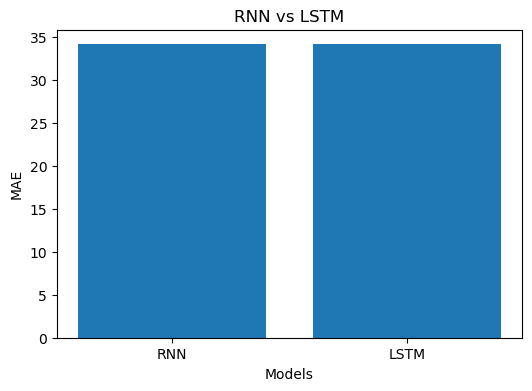

In [50]:
models = ['RNN', 'LSTM']
mae_values = [rnn_mae, lstm_mae]

plt.figure(figsize=(6,4))
plt.bar(models, mae_values)

plt.xlabel("Models")
plt.ylabel("MAE")
plt.title("RNN vs LSTM")

plt.show()